## Hw 1

### Part 1
Using a modified **10-armed Bandit** in this exercise to demonstrate the limitations of sample-average methods when dealing with nonstationary problems. We will compare two different action-value estimation methods: 

**Sample-average method** (SA).

**Constant step-size method** (CS).

##### 10-armed bandit:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random, math

np.random.seed(1)

class ten_armed_bandit:
    def __init__(self, k=10, walks=0.01):
        self.arms = k
        self.walks = 0.01
        self.q_t = np.zeros(k)

    def reward(self, arm):
        return np.random.normal(self.q_t[arm], 1)

    def update_q_t(self):
        self.q_t += np.random.normal(0, self.walks, self.arms)

    def find_best_arm(self):
        return np.argmax(self.q_t)


In [3]:
def run(k_arms=10,walks = 0.01, num_steps=10000, num_exp = 2000, ep=0.1, a_val = 0.1, sample_average=True):
    avg_rewards = np.zeros(num_steps)
    opt_arms = np.zeros(num_steps)

    for exp in range(num_exp):
        if exp % 10 == 0:
            print(f"Experiment {exp}/{num_exp} ...")

        bandit = ten_armed_bandit(k=k_arms, walks=walks)

        est_Q = np.zeros(bandit.arms) #Q values for each arm
        arm_counts = np.zeros(bandit.arms)

        for step in range(num_steps):
            if np.random.rand() < ep:
                arm = np.random.randint(bandit.arms)
            else:
                arm = np.argmax(est_Q)

            #reward
            reward = bandit.reward(arm) 
            
            bandit.update_q_t()
            opt_arm = bandit.find_best_arm()

            #update
            if sample_average == True:
                arm_counts[arm] += 1
                est_Q[arm] += (reward - est_Q[arm]) / arm_counts[arm]
            else:
                est_Q[arm] += a_val*(reward - est_Q[arm])
            
            #results
            avg_rewards[step] += reward
            if arm == opt_arm:
                opt_arms[step] += 1

    avg_rewards /= num_exp
    opt_arms = (opt_arms / num_exp) * 100 

    return avg_rewards, opt_arms

    


##### Constants

Defined some constant that will be used in the agent and update the reward

In [4]:
num_arms = 10  
num_steps = 10000  
num_exp = 2000  
epsilon = 0.1  
alpha = 0.1 
random_walks = 0.01 

##### Experiment

Experiment 0/2000 ...
Experiment 10/2000 ...
Experiment 20/2000 ...
Experiment 30/2000 ...
Experiment 40/2000 ...
Experiment 50/2000 ...
Experiment 60/2000 ...
Experiment 70/2000 ...
Experiment 80/2000 ...
Experiment 90/2000 ...
Experiment 100/2000 ...
Experiment 110/2000 ...
Experiment 120/2000 ...
Experiment 130/2000 ...
Experiment 140/2000 ...
Experiment 150/2000 ...
Experiment 160/2000 ...
Experiment 170/2000 ...
Experiment 180/2000 ...
Experiment 190/2000 ...
Experiment 200/2000 ...
Experiment 210/2000 ...
Experiment 220/2000 ...
Experiment 230/2000 ...
Experiment 240/2000 ...
Experiment 250/2000 ...
Experiment 260/2000 ...
Experiment 270/2000 ...
Experiment 280/2000 ...
Experiment 290/2000 ...
Experiment 300/2000 ...
Experiment 310/2000 ...
Experiment 320/2000 ...
Experiment 330/2000 ...
Experiment 340/2000 ...
Experiment 350/2000 ...
Experiment 360/2000 ...
Experiment 370/2000 ...
Experiment 380/2000 ...
Experiment 390/2000 ...
Experiment 400/2000 ...
Experiment 410/2000 ...
Exp

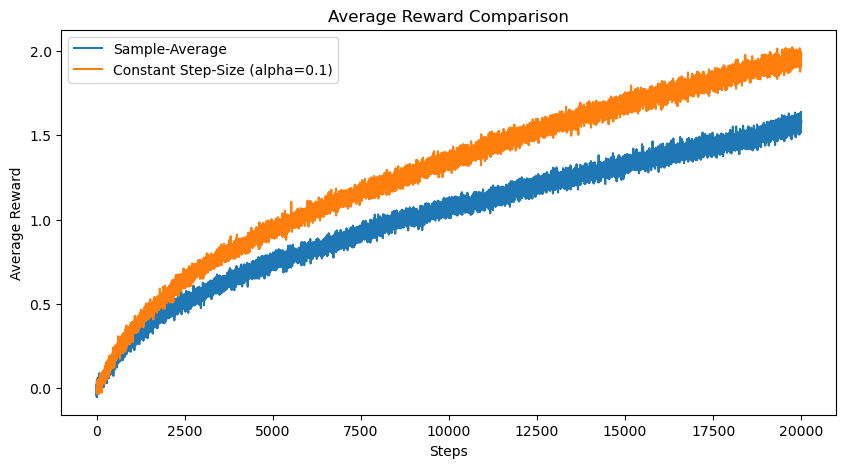

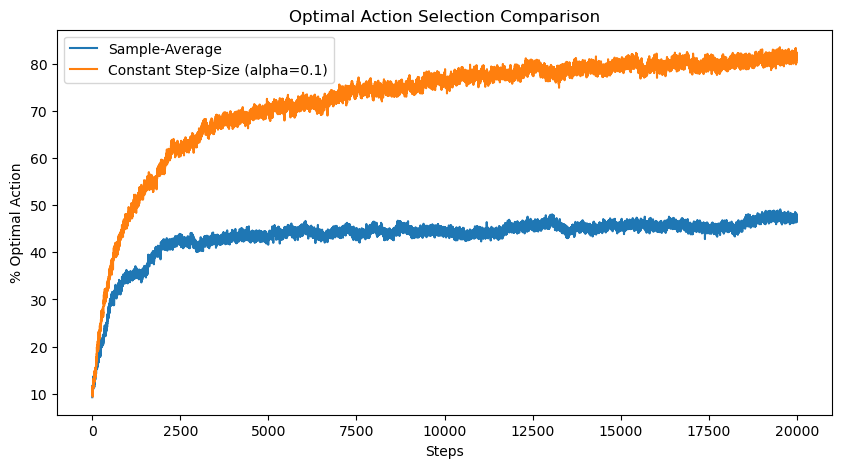

In [6]:

#run experiments
avg_rewards_SA, opt_arms_SA = run(num_arms, random_walks, num_steps, num_exp, epsilon, alpha, sample_average=True)
avg_rewards_CS, opt_arms_CS = run(num_arms, random_walks, num_steps, num_exp, epsilon, alpha, sample_average=False)

plt.figure(figsize=(10, 5))
plt.plot(avg_rewards_SA, label="Sample-Average")
plt.plot(avg_rewards_CS, label="Constant Step-Size (alpha=0.1)")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Average Reward Comparison")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(opt_arms_SA, label="Sample-Average")
plt.plot(opt_arms_CS, label="Constant Step-Size (alpha=0.1)")
plt.xlabel("Steps")
plt.ylabel("% Optimal Action")
plt.title("Optimal Action Selection Comparison")
plt.legend()
plt.show()

#### Try different parameters? Investigate the impact of different step-size values $alpha$ in the constant step-size method for a nonstationary 10-armed bandit.

Experiment 0/2000 ...
Experiment 10/2000 ...
Experiment 20/2000 ...
Experiment 30/2000 ...
Experiment 40/2000 ...
Experiment 50/2000 ...
Experiment 60/2000 ...
Experiment 70/2000 ...
Experiment 80/2000 ...
Experiment 90/2000 ...
Experiment 100/2000 ...
Experiment 110/2000 ...
Experiment 120/2000 ...
Experiment 130/2000 ...
Experiment 140/2000 ...
Experiment 150/2000 ...
Experiment 160/2000 ...
Experiment 170/2000 ...
Experiment 180/2000 ...
Experiment 190/2000 ...
Experiment 200/2000 ...
Experiment 210/2000 ...
Experiment 220/2000 ...
Experiment 230/2000 ...
Experiment 240/2000 ...
Experiment 250/2000 ...
Experiment 260/2000 ...
Experiment 270/2000 ...
Experiment 280/2000 ...
Experiment 290/2000 ...
Experiment 300/2000 ...
Experiment 310/2000 ...
Experiment 320/2000 ...
Experiment 330/2000 ...
Experiment 340/2000 ...
Experiment 350/2000 ...
Experiment 360/2000 ...
Experiment 370/2000 ...
Experiment 380/2000 ...
Experiment 390/2000 ...
Experiment 400/2000 ...
Experiment 410/2000 ...
Exp

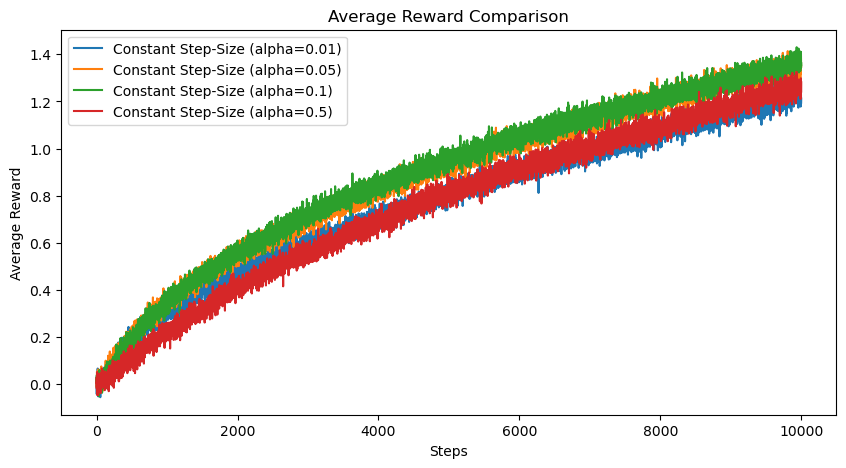

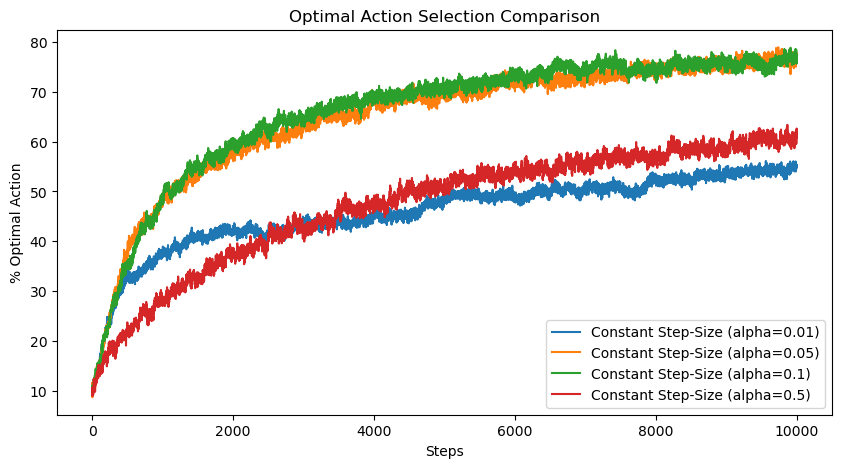

In [8]:
num_arms = 10  
num_steps = 10000  
num_exp = 2000  
epsilon = 0.1  
alpha_1 = 0.01 
alpha_2 = 0.05 
alpha_3 = 0.1 
alpha_4 = 0.5 
random_walks = 0.01 

#run experiments
avg_rewards_CS1, opt_arms_CS1 = run(num_arms, random_walks, num_steps, num_exp, epsilon, alpha_1, sample_average=False)
avg_rewards_CS2, opt_arms_CS2 = run(num_arms, random_walks, num_steps, num_exp, epsilon, alpha_2, sample_average=False)
avg_rewards_CS3, opt_arms_CS3 = run(num_arms, random_walks, num_steps, num_exp, epsilon, alpha_3, sample_average=False)
avg_rewards_CS4, opt_arms_CS4 = run(num_arms, random_walks, num_steps, num_exp, epsilon, alpha_4, sample_average=False)

plt.figure(figsize=(10, 5))
plt.plot(avg_rewards_CS1, label="Constant Step-Size (alpha=0.01)")
plt.plot(avg_rewards_CS2, label="Constant Step-Size (alpha=0.05)")
plt.plot(avg_rewards_CS3, label="Constant Step-Size (alpha=0.1)")
plt.plot(avg_rewards_CS4, label="Constant Step-Size (alpha=0.5)")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Average Reward Comparison")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(opt_arms_CS1, label="Constant Step-Size (alpha=0.01)")
plt.plot(opt_arms_CS2, label="Constant Step-Size (alpha=0.05)")
plt.plot(opt_arms_CS3, label="Constant Step-Size (alpha=0.1)")
plt.plot(opt_arms_CS4, label="Constant Step-Size (alpha=0.5)")
plt.xlabel("Steps")
plt.ylabel("% Optimal Action")
plt.title("Optimal Action Selection Comparison")
plt.legend()
plt.show()